In [ ]:
# n8n Supabase DDL 

# create table public.documents (
#   id bigserial not null,
#   content text null,
#   metadata jsonb null,
#   embedding extensions.vector null,
#   constraint documents_pkey primary key (id)
# ) TABLESPACE pg_default;

In [ ]:
# create or replace function match_documents (
#   query_embedding vector(1536),
#   match_count int default 5,
#   filter jsonb default '{}'
# ) returns table (
#   id bigint,
#   content text,
#   metadata jsonb,
#   similarity float
# )
# language plpgsql
# as $$
# begin
#   return query
#   select
#     documents.id,
#     documents.content,
#     documents.metadata,
#     1 - (documents.embedding <=> query_embedding) as similarity
#   from documents
#   where documents.metadata @> filter
#   order by documents.embedding <=> query_embedding
#   limit match_count;
# end;
# $$;

## ReAct Reasoning

## Reasoning Framework ( reason + acting) -> when it acts it basically connect with the tools 


## Tool 

- we defined a custom tools( add, multiply, divide) using @tool

- we used built-in tools of langchain

- you try bind the tools with llm

- LLM maps the tool bwhich one to be called


key concept:

- LLM decides which tool to call , with which arguments
- As a developer we execute the tool  and feed the result back to the Agent /LLM
- It uses tool output to observe ( either to reason further or not)


Typical Sequence:

- Thought : I need to lookup on 
- Action : execute
- Observation : tool output
- Thought : what shoud be done now (final answer is this)
- Answer : final answer returns back to the user


## How ReAct - RAG

vector store as retriver we can also use that as tool

ReAct :
 - It can able to decide when shoudl i call RAG vs other tool
 - I can do multiple retrival and reasoning
 

 Without React : you miss the reasoning power just a answer will be given out without proper checks.


 

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

if os.environ["OPENAI_API_KEY"] is None:
    raise ValueError("OPENAI_API_KEY environment variable not set.")
else:
    print("OPENAI_API_KEY environment variable is set.")


OPENAI_API_KEY environment variable is set.


In [13]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")


response = llm.invoke("Hello how are you?")
response.content

"Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to assist you. How can I help you today?"

In [6]:
from langchain.tools import tool

@tool
def multiply(a:int , b:int) -> int:
    """
    Multiplies two numbers together.
    Args:
    a(int) : The first integer
    b(int) : The Second integer

    Returns:
        int : The product of a and b
        """
    return a * b

@tool
def add(a:int, b:int) -> int:
    """
    Add two numbers together.
    Args:
    a(int) : The first integer
    b(int) : The Second integer

    Returns:
        int : The sum of a and b
    """
    return a+b

@tool
def division(a:int, b:int) -> int:
    """
    Divide two numbers together.
    Args:
    a(int) : The first integer
    b(int) : The Second integer

    Returns:
        int : The division of a and b
    """
    if b==0:
        raise ValueError("Denominator can't be zero")
    else:
       return  a/b


In [7]:
!pip3 install -qU duckduckgo-search langchain-community


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
!pip3 install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 2.2 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: primp
    Found existing installation: primp 0.15.0
    Uninstalling primp-0.15.0:
      Successfully uninstalled primp-0.15.0
  Attempting uninstall: ddgs
    Found existing installation: ddgs 9.10.0
    Uninstalling ddgs-9.10.0:
      Successfully uninstalled ddgs-9.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ddgs]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

search.invoke("who is the Donald Trump?")

'4 Feb 2026·Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. 17 Dec 2025·Donald John Trump (born June 14, 1946) is an American politician and businessman serving as the 47th president of the United States since 2025. 26 Nov 2025·Read CNN\'s Donald Trump Fast Facts to learn about the 47th president of the United States. 15 minutes ago·PTI THE HINDU President Trump says "we are ahead of schedule, and oil prices will decrease soon after the war is over". The situation in Iran is going very well ... 1 day ago·Almost two weeks into the war in Iran, Donald Trump\'s endgame remains elusive. He insists the US has won already, even as the bombs fall and Iran\'s drones ...'

In [11]:
tools = [add,multiply,division,search]

llm_bind_tools = llm.bind_tools(tools)

In [14]:
response = llm_bind_tools.invoke("Hi")

response.content

'Hello! How can I assist you today?'

In [15]:
response.tool_calls

[]

In [16]:
response = llm_bind_tools.invoke("2+2")
response.content

''

In [19]:
print(response.tool_calls)

tool_call = response.tool_calls[0]
tool_name = tool_call['name']
tool_arg = tool_call['args']

[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_zySUS3vm0pBS5QnKb9Se45tp', 'type': 'tool_call'}]


In [29]:
tool_map= {"add":add,
           "multiply":multiply,
           "division":division,
           "duckduckgo_search":search}

In [23]:
result = tool_map[tool_name].invoke(tool_arg)
result

4

In [25]:
response = llm_bind_tools.invoke("10/2")
response.tool_calls

[{'name': 'division',
  'args': {'a': 10, 'b': 2},
  'id': 'call_2Ee1mtWWrrMbdMyFvcH46r9W',
  'type': 'tool_call'}]

In [26]:
tool_call = response.tool_calls[0]
tool_name = tool_call['name']
tool_arg = tool_call['args']

result = tool_map[tool_name].invoke(tool_arg)
result

5.0

In [27]:
response = llm_bind_tools.invoke("who is CEO of TATA")
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'current CEO of TATA Group 2023'},
  'id': 'call_gl5zvwbkWe7ODo18I5suyKln',
  'type': 'tool_call'}]

In [30]:
tool_call = response.tool_calls[0]
tool_name = tool_call['name']
tool_arg = tool_call['args']

result = tool_map[tool_name].invoke(tool_arg)
result

"2 weeks ago -Natarajan Chandrasekaran(born 2 June 1963) is an Indian business executive. He is the chairman of Tata Sons and Tata Group. He was chief operating officer (COO) and executive director of Tata Consultancy Services (TCS), where in 2009, he became chief executive officer (CEO). 3 days ago -As of 2020, there have been seven chairs of the Tata Group. ... October 2021 – Air India, Air India Express and 50% stake in Air India SATS, ₹18,000 crore (US$2.1 billion). January 2022 – Nilachala Ispat Nigam Ltd, $1.5 billion · June 2023 – Kaleyra, Inc by Tata Communications, $100 million. July 29, 2025 -He was replaced byK.Krithivasan, the company's President and global head of banking, financial services and insurance (BFSI) vertical, who has been named CEO-designate effective 16 March 2023. 1 month ago -On 10 January 2020, however, the ... NCLAT. On 26 March 2021, the Supreme Court of India upheld Tata Sons' decision to sackCyrus Mistry.... November 24, 2025 -The board has nominatedK 

## Langgraph

In [141]:
from langchain_core.messages import HumanMessage, SystemMessage,AnyMessage
from langgraph.graph import StateGraph,START,END,MessagesState,add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from typing import TypedDict,Annotated

In [142]:
SYSTEM_PROMPT = '''
You are a helpful assistant tasked give responses to  user query based on the search and arithemetic 
operations whatever is applicable
'''

In [143]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]


In [144]:
def function1(state:MessagesState):
    userquestion = state["messages"]
    response = llm_bind_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + userquestion
    )

    return {"messages": [response]}

In [145]:
tools = [add,multiply,division,search]

In [146]:
builder = StateGraph(MessagesState)
builder.add_node("llm_decision_step",function1)
builder.add_node("tools",ToolNode(tools))

In [147]:
builder.add_edge(START,"llm_decision_step")
builder.add_conditional_edges("llm_decision_step",tools_condition)

builder.add_edge("tools","llm_decision_step")

In [148]:
react_graph = builder.compile()

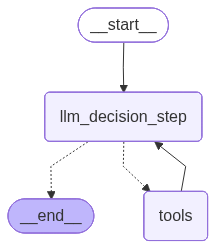

In [149]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [150]:
message = [HumanMessage(content=input())]
message

[HumanMessage(content='What is the speed of bullet train? and multiply it by 10', additional_kwargs={}, response_metadata={})]

In [151]:
response = react_graph.invoke({"messages":message})

In [159]:
response

{'messages': [HumanMessage(content='What is the speed of bullet train? and multiply it by 10', additional_kwargs={}, response_metadata={}, id='11e7fd85-5ced-4fed-a21e-2a29eee6394d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 275, 'total_tokens': 328, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1681c17ec', 'id': 'chatcmpl-DJBeGPkyY2dmGfW2M6YKYJdrbFhGX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ceac6-2361-7512-93c9-b09f9f00b7c9-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'speed of bullet train'}, 'id': 'call_gc2oKasgL62ahshEJ0SFEOeS', 'type': 'tool_call'}, {'name': 'multi

## Assignment


1. I want to create another tool (yfinance) -> where you get the stock price data pip install yfinance

2. this is the custom built tool -> this is will give you previus ending day stock when you pass the stock ticket symbol (abbrevations)

3. add this tool along with exsiting tool 


4. create end to end langgraph

5. Try to ask various question with search, stock, arithemetic operation together